In [1]:
import os
import numpy as np
from osgeo import gdal, osr
from sarpy.io.complex.sicd import SICDReader
from sarpy.geometry.geocoords import ecf_to_geodetic
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# アウトプットの保存先の設定
os.makedirs('../output/georeference/', exist_ok=True)
OUTPUT_DIR = '../output/georeference/'

In [32]:
# データのパスの設定
IMG_PATH = '../data/IMG-VV-STRIXB-20220829T142947Z-SLSLC-SICD.nitf'

# SICDファイルの読み込み
reader = SICDReader(IMG_PATH)

# 画像データの読み込み
data = reader[0]

# 振幅情報の抽出
amplitude = np.abs(data)

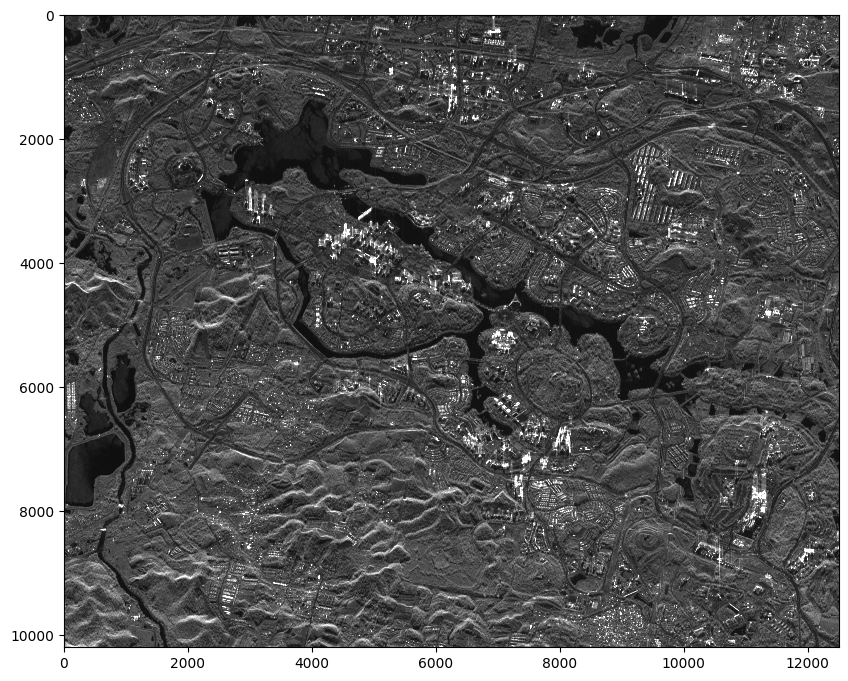

In [33]:
# 振幅情報の可視化
p2, p98 = np.percentile(amplitude, [2, 98])
plt.figure(figsize=(10,10))
plt.imshow(amplitude, cmap='gray', vmin=p2, vmax=p98);

In [34]:
# SICDファイルのメタ情報の取得
sicd_meta = reader.sicd_meta

print(sicd_meta)

SICDType(**{
 "CollectionInfo": {
  "CollectorName": "StriX-b",
  "CoreName": "20220829T142947",
  "CollectType": "MONOSTATIC",
  "RadarMode": {
   "ModeType": "DYNAMIC STRIPMAP",
   "ModeID": "SLR"
  },
  "Classification": "UNCLASSIFIED"
 },
 "ImageCreation": {
  "Application": "Doc Rev 0.1",
  "DateTime": "2023-12-18T10:29:57.507665Z",
  "Site": "SYNS",
  "Profile": "0.12.3"
 },
 "ImageData": {
  "PixelType": "RE32F_IM32F",
  "NumRows": 10193,
  "NumCols": 12500,
  "FirstRow": 0,
  "FirstCol": 0,
  "FullImage": {
   "NumRows": 10193,
   "NumCols": 12500
  },
  "SCPPixel": {
   "Row": 5096,
   "Col": 6250
  }
 },
 "GeoData": {
  "EarthModel": "WGS_84",
  "SCP": {
   "ECF": {
    "X": -1291276.645900045,
    "Y": 6237677.944871384,
    "Z": 323795.5976228509
   },
   "LLH": {
    "Lat": 2.929525146457647,
    "Lon": 101.6957338624693,
    "HAE": 73.69689840057129
   }
  },
  "ImageCorners": [
   {
    "Lat": 2.87581084708183,
    "Lon": 101.6582260625914,
    "index": "1:FRFC"
   },
  

In [35]:
# 基本メタ情報
num_rows = sicd_meta.ImageData.NumRows
num_cols = sicd_meta.ImageData.NumCols
img_rows = np.arange(num_rows) 
img_cols = np.arange(num_cols) 
scp_pos = sicd_meta.GeoData.SCP.ECF.get_array() 
scp_row = sicd_meta.ImageData.SCPPixel.Row 
scp_col = sicd_meta.ImageData.SCPPixel.Col
row_ss = sicd_meta.Grid.Row.SS
col_ss = sicd_meta.Grid.Col.SS
uRow = sicd_meta.Grid.Row.UVectECF.get_array()
uCol = sicd_meta.Grid.Col.UVectECF.get_array()

# グリッドの作成
X, Y = np.meshgrid(img_rows, img_cols, indexing='ij')

In [36]:
# SCP Pixel-Centered Image Indicesの作成
irow = X - scp_row
icol = Y - scp_col

# SCP Centered Image Coordinatesの作成
xrow = row_ss * irow
ycol = col_ss * icol

# SCPから各ピクセルまでの距離の計算
xrow = xrow[:, :, np.newaxis]
ycol = ycol[:, :, np.newaxis]
xIPP = xrow*uRow
yIPP = ycol*uCol

# IPP ECF Coordinatesの作成
IPP = scp_pos + xIPP + yIPP

In [8]:
# IPP ECF Coordinatesから緯度経度高度への変換（バッチ処理）
def batch_convert_ecf_to_geodetic(IPP, batch_size=10000):
    IPP_reshaped = IPP.reshape(-1, 3)
    total_points = IPP_reshaped.shape[0]

    num_batches = int(np.ceil(total_points / batch_size))

    IPP_geodetic_list = []
    for i in tqdm(range(num_batches), desc="Processing Batches"):
        start_idx = i * batch_size
        end_idx = min(start_idx + batch_size, total_points)
        batch = IPP_reshaped[start_idx:end_idx]    
        batch_results = [ecf_to_geodetic(ipp) for ipp in batch]
        IPP_geodetic_list.extend(batch_results)
    IPP_geodetic = np.array(IPP_geodetic_list).reshape(IPP.shape)
    
    return IPP_geodetic

IPP_geodetic = batch_convert_ecf_to_geodetic(IPP)

Processing Batches:   1%|          | 86/12742 [00:31<1:17:49,  2.71it/s]


KeyboardInterrupt: 

In [37]:
print(ecf_to_geodetic(IPP[0, 0]))
print(ecf_to_geodetic(IPP[10192, 0]))
print(ecf_to_geodetic(IPP[0, 12499]))
print(ecf_to_geodetic(IPP[10192, 12499]))
print(ecf_to_geodetic(IPP[scp_row, scp_col]))
print(sicd_meta.GeoData.SCP.LLH.get_array())

[   2.88381074  101.69755769 1958.65035964]
[    2.88659222   101.71169765 -1790.24634348]
[   2.97242544  101.67977962 1941.68971616]
[    2.9752596    101.69391023 -1807.21375054]
[  2.92952515 101.69573386  73.6968984 ]
[  2.92952515 101.69573386  73.6968984 ]
